## Computational Finance Lab Assignment 4
### Control Variates for Bond Pricing under the Black–Karasinski Model
#### Aleksandra Górska, Marcin Pałyga


## Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## Tasks

### Parameters

In [46]:
#BK
k=0.8
theta = np.log(0.03)
sigma = 0.03
#Vasicek
alpha = 0.8
beta = 0.03
eta = 0.03
#Bond
r0 = 0.03
T = 5
C = 0.04
dt = 1/52

### Functions

In [47]:
def BK_path(Z):
    ln_r = np.log(r0)
    rs = [r0]
    for z in Z:
        ln_r = ln_r + k*(theta-ln_r)*dt + sigma*np.sqrt(dt)*z
        rs.append(np.exp(ln_r))
    return rs

def vasicek_path(Z):
    r = r0
    rs = [r0]
    for z in Z:
        r = r + alpha*(beta-r)*dt + eta*np.sqrt(dt)*z
        rs.append(r)
    return rs

def disc_factor(rs, t):
    idx = int(t/dt)
    disc = 0
    for i in range(1, idx+1):
        disc += 0.5*(rs[i-1]+rs[i])*dt
    return np.exp(-disc)

def bond(rs):
    price = 0
    for i in range(1, T+1):
        D = disc_factor(rs, i)
        price += C*D
    price += disc_factor(rs, T)
    return price

def vasicek_price():
    B = (1-np.exp(-alpha*T))/alpha
    A = (beta-eta**2/(2*alpha**2))*(B-T)-eta**2/(4*alpha)*B**2
    return np.exp(A-B*r0)

### Simulations

In [48]:
#pre-run
N=1000
X=np.zeros(N)
Y=np.zeros(N)
for i in range(N):
    Z = np.random.normal(0, 1, int(T/dt))
    r_bk = BK_path(Z)
    Y[i] = bond(r_bk)

    r_vas = vasicek_path(Z)
    X[i] = disc_factor(r_vas, T)
nu_hat = np.mean((Y-np.mean(Y))*(X-np.mean(X)))/np.mean((X-np.mean(X))**2)

In [49]:
N=10000
Y = np.zeros(N)
X = np.zeros(N)
Y_anti = np.zeros(N)
X_anti = np.zeros(N)
for i in range(N):
    Z = np.random.normal(0, 1, int(T/dt))

    r_bk = BK_path(Z)
    Y[i] = bond(r_bk)
    r_vas = vasicek_path(Z)
    X[i] = disc_factor(r_vas, T)

    r_bk_anti = BK_path(-Z)
    Y_anti[i] = bond(r_bk_anti)
    r_vas_anti = vasicek_path(-Z)
    X_anti[i] = disc_factor(r_vas_anti, T)

### Task 1.

In [57]:
V_MC = np.mean(Y)
MC_err = np.std(Y)/np.sqrt(N)
MC_var = np.var(Y)
print(f'Naive Monte Carlo price is {V_MC:.4f} with standard error {MC_err:.6f} and variance of {MC_var:.6f}')

Naive Monte Carlo price is 1.0436 with standard error 0.000019 and variance of 0.000004


### Task 2

In [63]:
mu_X = vasicek_price()
cov = np.cov(Y,X)[0,1]
print(f'Simulated expected value of X {np.mean(X):.4f} and exact value {mu_X:.4f}')
print(f'Covariance of Y and X: {cov:.4f}')

Simulated expected value of X 0.8625 and exact value 0.8626
Covariance of Y and X: 0.0001


### Task 3 & 4

In [88]:
Y_CV = Y-nu_hat*(X-mu_X)
V_CV = np.mean(Y_CV)
CV_err = np.std(Y_CV)/np.sqrt(N)
CV_var = np.var(Y_CV)
VRF_CV = MC_var/CV_var
print(f"Value of nu_hat from pre-run with 1000 simulations {nu_hat:.4f}")
print(f"Control variate price is {V_CV:.4f} with standard error {CV_err:.6f} and variance of {CV_var:.8f}")
print(f"Variance reduction factor for control variate method is equal to {VRF_CV:.4f}")

Value of nu_hat from pre-run with 1000 simulations 0.0331
Control variate price is 1.0436 with standard error 0.000001 and variance of 0.00000002
Variance reduction factor for control variate method is equal to 220.5053


### Task 5

Original (α=0.8, β=0.03, η=0.03)         0.0334     0.9979     222.63     312.75    
Low α (α=0.3, β=0.03, η=0.03)            0.0331     0.9977     223.46     317.41    
High α (α=1.5, β=0.03, η=0.03)           0.0334     0.9979     218.19     311.36    
Low β (α=0.8, β=0.02, η=0.03)            0.0332     0.9976     221.09     321.45    
High β (α=0.8, β=0.05, η=0.03)           0.0332     0.9977     219.96     308.15    
Low η (α=0.8, β=0.03, η=0.01)            0.0333     0.9976     214.82     298.51    
High η (α=0.8, β=0.03, η=0.05)           0.0333     0.9978     225.53     323.75    


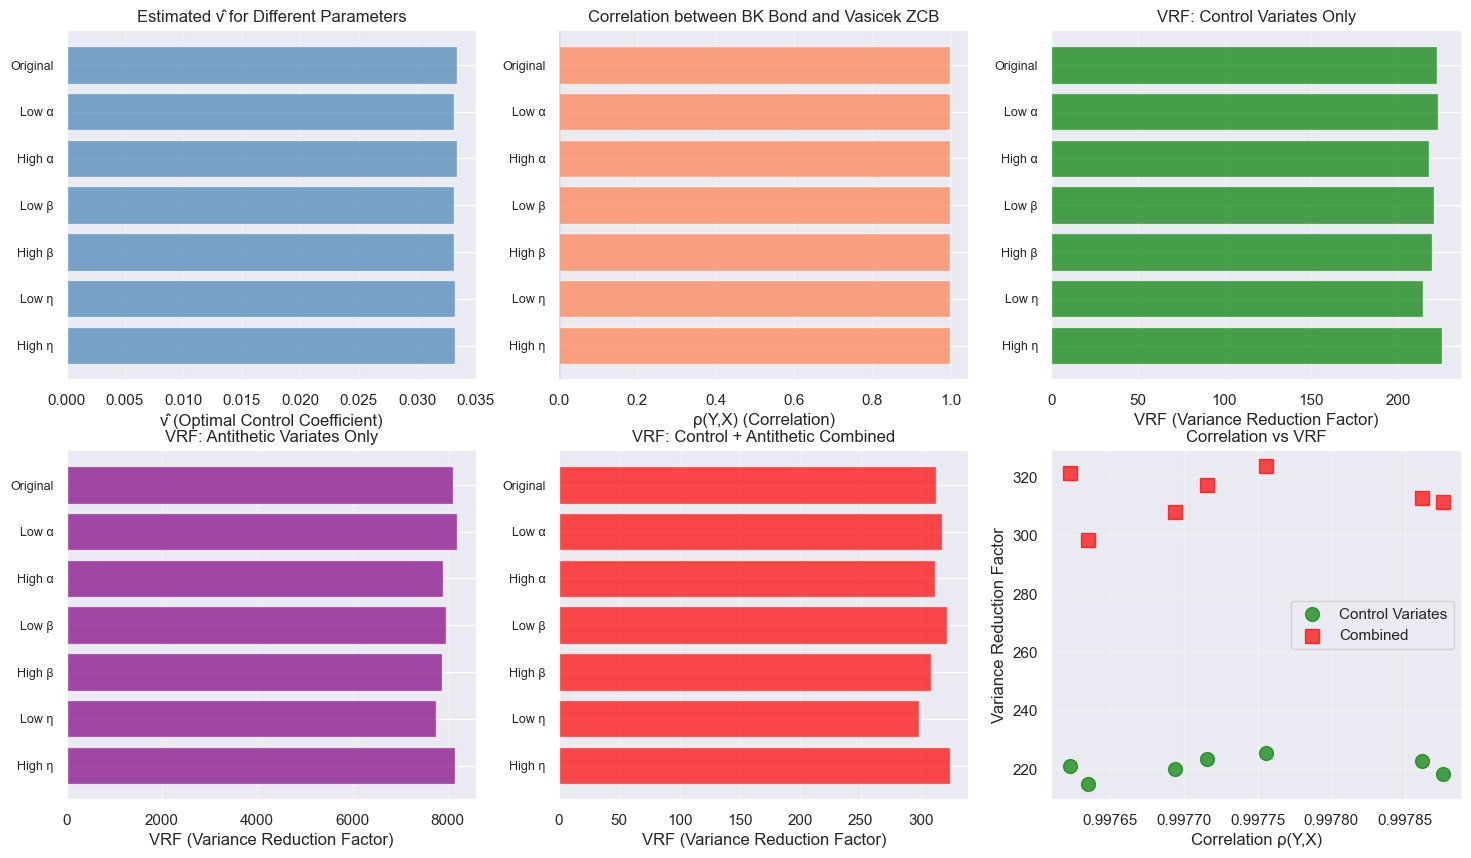

In [104]:
def run_experiment(alpha, beta, eta, N_prerun=1000, N_main=10000):
    
    X=np.zeros(N_prerun)
    Y=np.zeros(N_prerun)
    for i in range(N_prerun):
        Z = np.random.normal(0, 1, int(T/dt))
        r_bk = BK_path(Z)
        Y[i] = bond(r_bk)

        r_vas = vasicek_path(Z)
        X[i] = disc_factor(r_vas, T)
    nu_hat = np.mean((Y-np.mean(Y))*(X-np.mean(X)))/np.mean((X-np.mean(X))**2)
    corr = np.corrcoef(Y, X)[0, 1]
    mu_X = vasicek_price()
    
    Y = np.zeros(N_main)
    X = np.zeros(N_main)
    Y_anti = np.zeros(N_main)
    X_anti = np.zeros(N_main)
    
    for i in range(N_main):
        Z = np.random.normal(0, 1, int(T/dt))
        
        r_bk = BK_path(Z)
        Y[i] = bond(r_bk)
        r_vas = vasicek_path(Z)
        X[i] = disc_factor(r_vas, T)
        
        r_bk_anti = BK_path(-Z)
        Y_anti[i] = bond(r_bk_anti)
        r_vas_anti = vasicek_path(-Z)
        X_anti[i] = disc_factor(r_vas_anti, T)
    
    Var_MC = np.var(Y)
    
    Y_CV = Y - nu_hat * (X - mu_X)
    Var_CV = np.var(Y_CV)
    VRF_CV = Var_MC / Var_CV
    
    Y_AV = (Y + Y_anti) / 2
    Var_AV = np.var(Y_AV)
    VRF_AV = Var_MC / Var_AV
    
    Y_CV_anti = Y_anti - nu_hat * (X_anti - mu_X)
    Y_CVAV = (Y_CV + Y_CV_anti) / 2
    Var_CVAV = np.var(Y_CVAV)
    VRF_CVAV = Var_MC / Var_CVAV
    
    return {
        'nu_hat': nu_hat,
        'corr': corr,
        'mu_X': mu_X,
        'Var_MC': Var_MC,
        'Var_CV': Var_CV, 'VRF_CV': VRF_CV,
        'Var_AV': Var_AV, 'VRF_AV': VRF_AV,
        'Var_CVAV': Var_CVAV, 'VRF_CVAV': VRF_CVAV,
    }
param_sets = [
    {'name': 'Original (α=0.8, β=0.03, η=0.03)', 'alpha': 0.8, 'beta': 0.03, 'eta': 0.03},
    
    {'name': 'Low α (α=0.3, β=0.03, η=0.03)', 'alpha': 0.3, 'beta': 0.03, 'eta': 0.03},
    {'name': 'High α (α=1.5, β=0.03, η=0.03)', 'alpha': 1.5, 'beta': 0.03, 'eta': 0.03},
    
    {'name': 'Low β (α=0.8, β=0.02, η=0.03)', 'alpha': 0.8, 'beta': 0.02, 'eta': 0.03},
    {'name': 'High β (α=0.8, β=0.05, η=0.03)', 'alpha': 0.8, 'beta': 0.05, 'eta': 0.03},
    
    {'name': 'Low η (α=0.8, β=0.03, η=0.01)', 'alpha': 0.8, 'beta': 0.03, 'eta': 0.01},
    {'name': 'High η (α=0.8, β=0.03, η=0.05)', 'alpha': 0.8, 'beta': 0.03, 'eta': 0.05},

]

results = []
for params in param_sets:
    result = run_experiment(params['alpha'], params['beta'], params['eta'])
    result['name'] = params['name']
    result['alpha'] = params['alpha']
    result['beta'] = params['beta']
    result['eta'] = params['eta']
    results.append(result)


for r in results:
    print(f"{r['name']:<40} {r['nu_hat']:<10.4f} {r['corr']:<10.4f} {r['VRF_CV']:<10.2f} {r['VRF_CVAV']:<10.2f}")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

names_short = [r['name'].split('(')[0].strip() for r in results]
nu_values = [r['nu_hat'] for r in results]
axes[0, 0].barh(range(len(results)), nu_values, color='steelblue', alpha=0.7)
axes[0, 0].set_yticks(range(len(results)))
axes[0, 0].set_yticklabels(names_short, fontsize=9)
axes[0, 0].set_xlabel('ν̂ (Optimal Control Coefficient)')
axes[0, 0].set_title('Estimated ν̂ for Different Parameters')
axes[0, 0].grid(True, alpha=0.3, axis='x')
axes[0, 0].invert_yaxis()

corr_values = [r['corr'] for r in results]
axes[0, 1].barh(range(len(results)), corr_values, color='coral', alpha=0.7)
axes[0, 1].set_yticks(range(len(results)))
axes[0, 1].set_yticklabels(names_short, fontsize=9)
axes[0, 1].set_xlabel('ρ(Y,X) (Correlation)')
axes[0, 1].set_title('Correlation between BK Bond and Vasicek ZCB')
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].axvline(0, color='black', linewidth=0.8)
axes[0, 1].invert_yaxis()

vrf_cv = [r['VRF_CV'] for r in results]
axes[0, 2].barh(range(len(results)), vrf_cv, color='green', alpha=0.7)
axes[0, 2].set_yticks(range(len(results)))
axes[0, 2].set_yticklabels(names_short, fontsize=9)
axes[0, 2].set_xlabel('VRF (Variance Reduction Factor)')
axes[0, 2].set_title('VRF: Control Variates Only')
axes[0, 2].grid(True, alpha=0.3, axis='x')
axes[0, 2].invert_yaxis()

vrf_av = [r['VRF_AV'] for r in results]
axes[1, 0].barh(range(len(results)), vrf_av, color='purple', alpha=0.7)
axes[1, 0].set_yticks(range(len(results)))
axes[1, 0].set_yticklabels(names_short, fontsize=9)
axes[1, 0].set_xlabel('VRF (Variance Reduction Factor)')
axes[1, 0].set_title('VRF: Antithetic Variates Only')
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].invert_yaxis()

vrf_cvav = [r['VRF_CVAV'] for r in results]
axes[1, 1].barh(range(len(results)), vrf_cvav, color='red', alpha=0.7)
axes[1, 1].set_yticks(range(len(results)))
axes[1, 1].set_yticklabels(names_short, fontsize=9)
axes[1, 1].set_xlabel('VRF (Variance Reduction Factor)')
axes[1, 1].set_title('VRF: Control + Antithetic Combined')
axes[1, 1].grid(True, alpha=0.3, axis='x')
axes[1, 1].invert_yaxis()

axes[1, 2].scatter(corr_values, vrf_cv, s=100, alpha=0.7, c='green', label='Control Variates')
axes[1, 2].scatter(corr_values, vrf_cvav, s=100, alpha=0.7, c='red', marker='s', label='Combined')
axes[1, 2].set_xlabel('Correlation ρ(Y,X)')
axes[1, 2].set_ylabel('Variance Reduction Factor')
axes[1, 2].set_title('Correlation vs VRF')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

### Task 6

In [94]:
V_AV = np.mean((Y+Y_anti)/2)
AV_err = np.std((Y+Y_anti)/2)/np.sqrt(N)
AV_var = np.var((Y+Y_anti)/2)
VRF_AV = MC_var/AV_var
print(f"Antithetic variates price is {V_AV:.4f} with standard error {AV_err:.7f} and variance of {AV_var:.10f}")
print(f"Variance reduction factor for antithetic variates method is equal to {VRF_AV:.4f}")

Antithetic variates price is 1.0436 with standard error 0.0000002 and variance of 0.0000000005
Variance reduction factor for antithetic variates method is equal to 8040.2696


### Task 7

In [97]:
Y_CV_anti = Y_anti - nu_hat*(X_anti-mu_X)
Y_CVAV = (Y_CV+Y_CV_anti)/2
V_CVAV = np.mean(Y_CVAV)
CVAV_err = np.std(Y_CVAV)/np.sqrt(N)
CVAV_var = np.var(Y_CVAV)
VRF_CVAV = MC_var/CVAV_var
print(f"Price using combination of methods is {V_CVAV:.4f} with standard error {CVAV_err:.6f} and variance of {CVAV_var:.8f}")
print(f"Variance reduction factor for combination of methods is equal to {VRF_CVAV:.4f}")

Price using combination of methods is 1.0436 with standard error 0.000001 and variance of 0.00000001
Variance reduction factor for combination of methods is equal to 321.0952


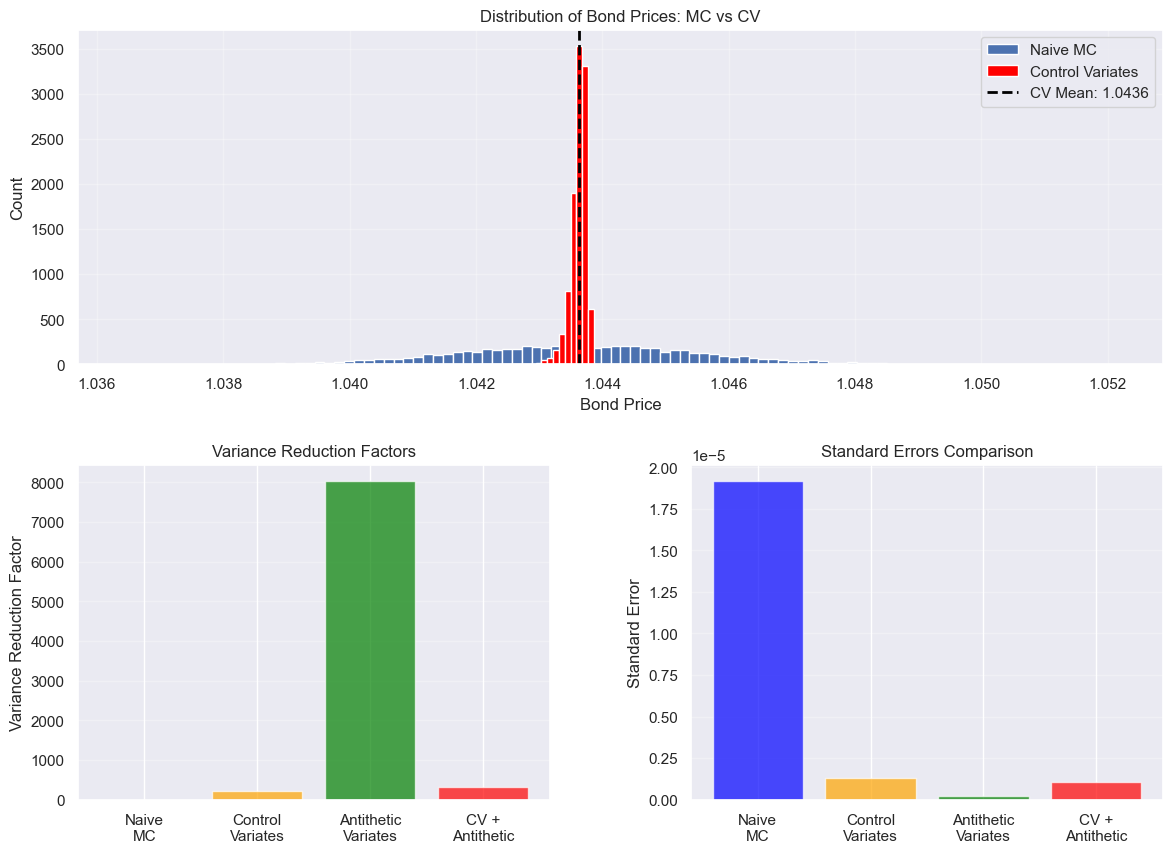

In [121]:
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.hist(Y, bins='sqrt', label='Naive MC', density=True)
ax1.hist(Y_CV, bins=20, label='Control Variates', density=True, color='red')
ax1.axvline(V_CV, color='black', linestyle='--', linewidth=2, label=f'CV Mean: {V_CV:.4f}')
ax1.set_xlabel('Bond Price')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Bond Prices: MC vs CV')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
methods = ['Naive\nMC', 'Control\nVariates', 'Antithetic\nVariates', 'CV +\nAntithetic']
vrfs = [1.0, VRF_CV, VRF_AV, VRF_CVAV]
colors = ['blue', 'orange', 'green', 'red']
ax2.bar(methods, vrfs, color=colors, alpha=0.7)
ax2.set_ylabel('Variance Reduction Factor')
ax2.set_title('Variance Reduction Factors')
ax2.grid(True, alpha=0.3, axis='y')

ax3 = fig.add_subplot(gs[1, 1])
std_errs = [MC_err, CV_err, AV_err, CVAV_err]
ax3.bar(methods, std_errs, color=colors, alpha=0.7)
ax3.set_ylabel('Standard Error')
ax3.set_title('Standard Errors Comparison')
ax3.grid(True, alpha=0.3, axis='y')

plt.show()

Antithetic variates produces the highest VRF and the smallest standard errors as clearly seen on the bar plots. Even with smaller VRF produced by Control Variates method we can see that the distribution of prices are far less spread out than using naive Monte Carlo.